## Introduction

Seattle, Washington, has a reputation as the rainy city of the United States. This project tests that reputation by comparing Seattle with New York City using five years of daily precipitation records (2018-2022).

A city could have many days of light drizzle and still receive less total water than a city with fewer, heavier storms. “More rain” can mean how much rain falls or how often it rains. The analysis therefore compares the cities on both measures, overall and month by month, and uses hypothesis tests to check whether the monthly differences are larger than what chance alone could produce.

The notebook follows the data science methodology:
- **Data preparation:** inspect, clean, and combine the two data sets.
- **Exploratory data analysis:** summarize and plot the data to compare the cities.
- **Hypothesis tests:** test, for each month, whether the cities differ in the average amount of precipitation and in the proportion of days with precipitation.
- **Checks and conclusion:** check how much the filled-in Seattle days affect the results, reproduce the statistics and figures used in the report, and answer the question.

## Data sources

- Seattle, WA: Daily weather observations from the Seattle 2.1 ESE station, provided with the course: [DATA 5100 weather repository](https://github.com/brian-fischer/DATA-5100/tree/main/weather) | `data/seattle_rain.csv` |
- New York City, NY: Daily weather observations from the Central Park station, from the NOAA National Centers for Environmental Information: [Climate Data Online](https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND) | `data/nyc_rain.csv` | 

Both files hold one row per day. The columns used are `DATE` and `PRCP` (daily precipitation in inches). The files cover January 1, 2018, to December 31, 2022.

## 1. Load and explore the data

### Import libraries
**Purpose:** load the libraries used throughout: pandas for data frames, numpy for array operations, and matplotlib and seaborn for plots.

In [7]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn as a data visualization library built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

### Load the data
**Purpose:** read the two raw CSV files into data frames and preview the first rows to see the column names and example values.

In [9]:
df_seattle = pd.read_csv("../data/seattle_rain.csv")
df_nyc = pd.read_csv("../data/nyc_rain.csv")
type(df_seattle)
type(df_nyc)

pandas.core.frame.DataFrame

### Explore the contents of the data sets

In [11]:
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [12]:
df_nyc.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00094728,"NY CITY CENTRAL PARK, NY US",2018-01-01,0.00,0.0,0.0
1,USW00094728,"NY CITY CENTRAL PARK, NY US",2018-01-02,0.00,0.0,0.0
2,USW00094728,"NY CITY CENTRAL PARK, NY US",2018-01-03,0.00,0.0,0.0
3,USW00094728,"NY CITY CENTRAL PARK, NY US",2018-01-04,0.76,9.8,1.2
4,USW00094728,"NY CITY CENTRAL PARK, NY US",2018-01-05,0.00,0.0,7.1


In [13]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='object')

In [14]:
df_nyc.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='object')

Both files hold one row per day for one weather station, with identifiers (`STATION`, `NAME`), the date (`DATE`), and precipitation in inches (`PRCP`). The Seattle date is written like `1/1/18`, while NYC uses `2018-01-01`, so the two date columns will need separate formats. Seattle also has extra columns (such as `DAPR` and `WESD`) that are mostly empty.

### Compare columns, data types, and missing values
**Purpose:** list the columns of each data set and use `info()` to see the data types and how many non-null values each column has. This reveals which columns are usable and where data is missing.

In [17]:
df_seattle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   object 
 1   NAME     1658 non-null   object 
 2   DATE     1658 non-null   object 
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), object(3)
memory usage: 129.7+ KB


In [18]:
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   object 
 1   NAME     1826 non-null   object 
 2   DATE     1826 non-null   object 
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


Seattle has 10 columns and NYC has 6, so the columns are not entirely the same, but both contain `DATE` and `PRCP`, the only two we need. `DATE` is stored as text (object) in both files. In Seattle, `PRCP` has 1,636 non-null values out of 1,658 rows, so 22 precipitation values are missing, while NYC `PRCP` has no missing values. Seattle's other columns (`DAPR`, `MDPR`, `SNOW`, ...) are mostly empty.

### Compare the sizes of the data sets
**Purpose:** use `shape` to compare the number of rows. Five years of daily data should have 5 x 365 + 1 = 1,826 days (2020 is a leap year), so a smaller data set means some dates are not recorded.

In [21]:
print(df_seattle.shape)
print(df_nyc.shape)

(1658, 10)
(1826, 6)


NYC has 1,826 rows, exactly the expected number of days. Seattle has only 1,658 rows, so 168 dates are missing entirely from the Seattle file. This is a second kind of missing data, in addition to the 22 empty `PRCP` values.

#### Examine the STATION column: how many weather stations are in each data set?
**Purpose:** confirm that each file comes from a single station. If a file contained several stations, we would have to filter to one to avoid mixing locations.

In [24]:
print(df_seattle['STATION'].nunique())
print(df_nyc['STATION'].nunique())

1
1


Each data set has exactly one station: Seattle 2.1 ESE and New York City Central Park. No station filtering is needed.

### Convert DATE to datetime
**Purpose:** `DATE` is currently text, so it cannot be sorted, compared, or used to extract months correctly. Convert it with `pd.to_datetime`, giving the format of each file explicitly because the two files write dates differently.

In [27]:
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'], format='%m/%d/%y')
df_nyc['DATE'] = pd.to_datetime(df_nyc['DATE'], format='%Y-%m-%d')

In [28]:
df_seattle['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1653   2022-12-27
1654   2022-12-28
1655   2022-12-29
1656   2022-12-30
1657   2022-12-31
Name: DATE, Length: 1658, dtype: datetime64[ns]

In [29]:
df_nyc['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1821   2022-12-27
1822   2022-12-28
1823   2022-12-29
1824   2022-12-30
1825   2022-12-31
Name: DATE, Length: 1826, dtype: datetime64[ns]

#### What range of dates are present?

In [31]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

In [32]:
df_nyc['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

Both columns are now `datetime64`. Both data sets cover January 1, 2018 through December 31, 2022, so the cities cover the same period and no date filtering is needed.

### Plot the raw daily precipitation of each city
**Purpose:** visually check that the data is suitable for comparing the cities: look for the typical size of daily values, extreme values, and anything unexpected.

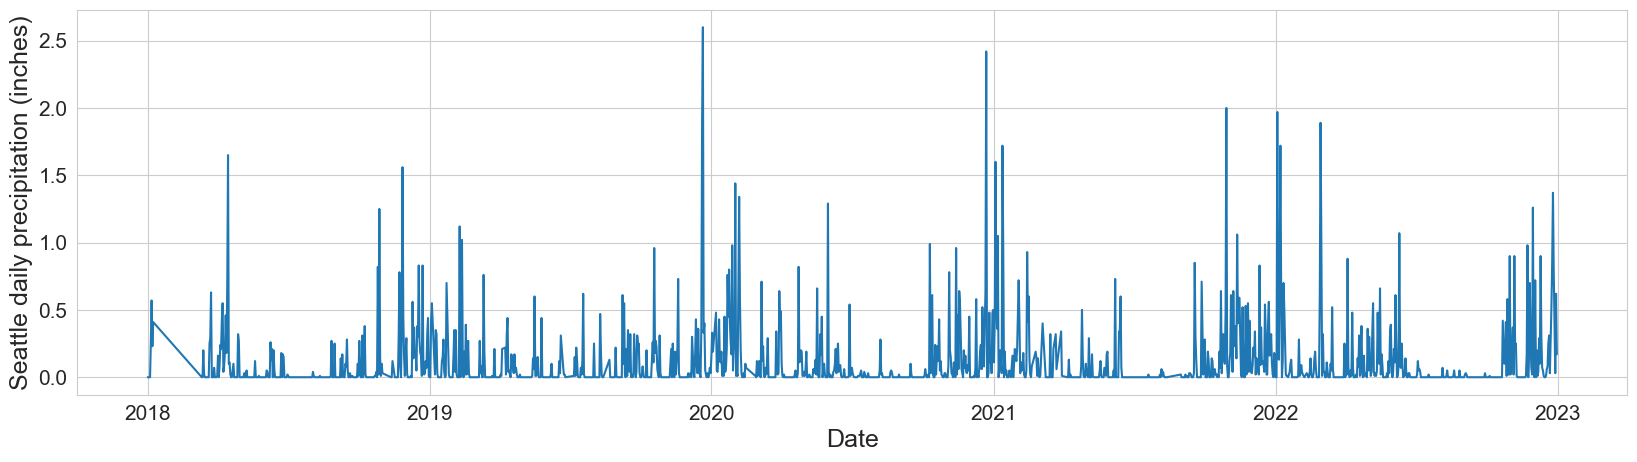

In [35]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=df_seattle, x='DATE', y='PRCP')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Seattle daily precipitation (inches)', fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

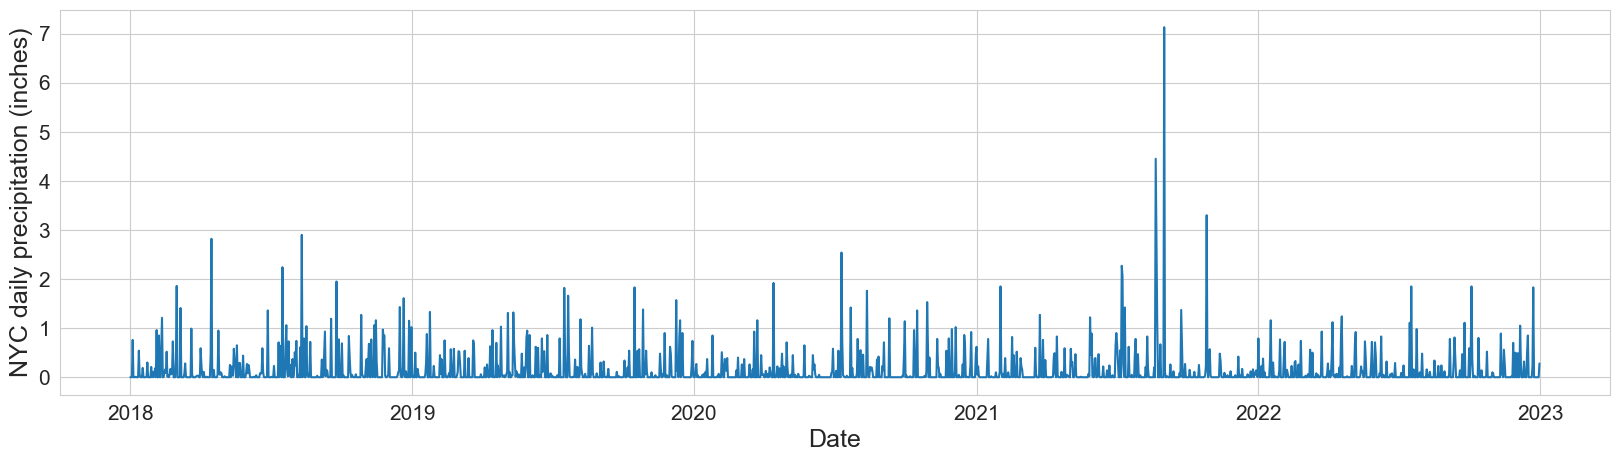

In [36]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=df_nyc, x='DATE', y='PRCP')
plt.xlabel('Date', fontsize=18)
plt.ylabel('NYC daily precipitation (inches)', fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

In both cities most days have little or no rain, with occasional spikes. Seattle's largest day is about 2.6 inches, while NYC has a much larger extreme of 7.13 inches. The data looks reasonable and usable.

### Check for duplicate and omitted dates
**Purpose:** compare each file's dates with the complete list of days from 2018-01-01 to 2022-12-31 to count exactly how many dates are omitted, and check that no date appears twice.

In [39]:
all_dates = pd.date_range('2018-01-01', '2022-12-31')
print('Expected number of days:', len(all_dates))
print('Seattle rows:', df_seattle.shape[0], '| omitted dates:', len(all_dates.difference(df_seattle['DATE'])))
print('NYC rows:    ', df_nyc.shape[0], '| omitted dates:', len(all_dates.difference(df_nyc['DATE'])))
print('Duplicate dates - Seattle:', df_seattle['DATE'].duplicated().sum(), '| NYC:', df_nyc['DATE'].duplicated().sum())

Expected number of days: 1826
Seattle rows: 1658 | omitted dates: 168
NYC rows:     1826 | omitted dates: 0
Duplicate dates - Seattle: 0 | NYC: 0


There are 1,826 expected days. NYC has no omitted dates, and Seattle has 168. Neither file has duplicate dates. Together with the 22 empty Seattle `PRCP` values, Seattle will have 190 missing precipitation values to fix.

### Join data frames keeping DATE and PRCP columns
**Purpose:** keep only `DATE` and `PRCP` and combine the cities into one data frame by date. An outer join keeps every date from either file, so Seattle's omitted dates appear as rows with a missing (NaN) value instead of silently disappearing.

In [42]:
df = df_nyc[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']], on='DATE', how='outer')
df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.76,0.00
4,2018-01-05,0.00,0.25


In [43]:
df.describe()

,DATE,PRCP_x,PRCP_y
count,1826,1826.000000,1636.000000
mean,2020-07-01 12:00:00,0.147842,0.111852
min,2018-01-01 00:00:00,0.000000,0.000000
25%,2019-04-02 06:00:00,0.000000,0.000000
50%,2020-07-01 12:00:00,0.000000,0.010000
75%,2021-09-30 18:00:00,0.080000,0.110000
max,2022-12-31 00:00:00,7.130000,2.600000
std,NaN,0.388334,0.248635


The joined data frame has 1,826 rows (one per day). Both files had a `PRCP` column, so pandas added suffixes: `PRCP_x` is NYC and `PRCP_y` is Seattle. NYC has 1,826 precipitation values, while Seattle has 1,636, so 190 Seattle values are missing, matching the earlier count. Before any fixing, the mean daily precipitation is about 0.148 inches for NYC and 0.112 inches for Seattle.

### Create a tidy data frame with columns for city and precipitation
**Purpose:** convert the data to tidy format with one row per city per day, so one column holds the city and one holds the precipitation.

In [46]:
# use DATE as the identifier variable
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [47]:
df

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.76
4,2018-01-05,PRCP_x,0.00
...,...,...,...
3647,2022-12-27,PRCP_y,0.78
3648,2022-12-28,PRCP_y,0.40
3649,2022-12-29,PRCP_y,0.03
3650,2022-12-30,PRCP_y,0.62


The data frame now has 3,652 rows (2 cities x 1,826 days) and three columns: `DATE`, `city` (`NYC` or `SEA`), and `precipitation`. The head shows NYC rows and the tail shows Seattle rows.

### Rename columns or values to follow best practices
**Purpose:** give the columns and values clear names. Tidy data makes grouping and plotting by city simple.

In [50]:
df.loc[df['city']== 'PRCP_x', 'city'] = 'NYC'
df.loc[df['city']== 'PRCP_y', 'city'] = 'SEA'

In [51]:
df.head()

,DATE,city,precipitation
0,2018-01-01,NYC,0.00
1,2018-01-02,NYC,0.00
2,2018-01-03,NYC,0.00
3,2018-01-04,NYC,0.76
4,2018-01-05,NYC,0.00


In [52]:
df.tail()

,DATE,city,precipitation
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62
3651,2022-12-31,SEA,0.17


In [53]:
# Rename the columns to be lowercase using df.rename()
df = df.rename(columns={'DATE': 'date'})
df.head()

,date,city,precipitation
0,2018-01-01,NYC,0.00
1,2018-01-02,NYC,0.00
2,2018-01-03,NYC,0.00
3,2018-01-04,NYC,0.76
4,2018-01-05,NYC,0.00


### Identify and fill in missing values
**Purpose:** confirm where the missing values are before fixing them, overall and for each city.

In [55]:
# Count the non-null or null values
df.info()
df.notna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3462 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 85.7+ KB


date             3652
city             3652
precipitation    3462
dtype: int64

In [56]:
# Determine the number of null values in each column
df.isna().sum()

date               0
city               0
precipitation    190
dtype: int64

In [57]:
# Determine the number of null precipitation values for Seattle and NYC
print(df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum())
print(df.loc[df['city'] == 'NYC', 'precipitation'].isna().sum())

190
0


The only column with missing values is `precipitation`, with 190 missing. All 190 belong to Seattle (NYC has 0), exactly the 168 omitted dates plus 22 empty values found earlier.

### Impute missing values
**Purpose:** fill each missing Seattle value with the average Seattle precipitation for the same day of the year across the years. The algorithm is: (1) label each row with its day of the year, (2) compute the mean for each day of the year, (3) find the missing rows, (4) replace each one with the mean for its day.

#### Label each row with its day of the year
This is step (1).

In [61]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,NYC,0.00,1
1,2018-01-02,NYC,0.00,2
2,2018-01-03,NYC,0.00,3
3,2018-01-04,NYC,0.76,4
4,2018-01-05,NYC,0.00,5


The new `day_of_year` column runs from 1 (January 1) to 365, or 366 in the leap year 2020.

#### Compute the mean precipitation for each day in Seattle, averaged across years.
Step (2): average Seattle's precipitation across years for each day of the year. These means are the replacement values. The plot shows the pattern, and the final line checks that no day lacks a mean to fill with.

In [64]:
mean_day_precipitation=df.loc[
    df['city']=='SEA',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

In [65]:
mean_day_precipitation

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


In [66]:
# make sure every day of the year has a mean to fill with
mean_day_precipitation['precipitation'].isna().sum()

0

There is a mean for all 366 days, none missing, so every gap can be filled.

#### Get the index of each row where precipitation is missing.
Steps (3): find the row positions where precipitation is missing.

In [69]:
indices = np.where(df['precipitation'].isna() == True)[0]
indices

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

#### Replace each missing value with the mean on that day
Step (4): replace each with the mean for that row's day of the year.

In [71]:
# use for loop to iterate in this array
for index in indices:
    df.loc[index,'precipitation'] = mean_day_precipitation.loc[df.loc[index, 'day_of_year']].values[0]

The loop found 190 missing values, matching the earlier count, and replaced them.

#### Check for missing values in the data frame
**Purpose:** confirm that no missing values remain, that the size is correct, and that the summary statistics look sensible. The plot shows the cleaned data for both cities.

In [74]:
print(df.isna().sum())
print(df.shape)
print(df.groupby('city')['precipitation'].describe())

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64
(3652, 4)
       count      mean       std  min  25%   50%   75%   max
city                                                        
NYC   1826.0  0.147842  0.388334  0.0  0.0  0.00  0.08  7.13
SEA   1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.60


There are no missing values left and the data frame still has 3,652 rows. Each city now has 1,826 values. The imputation barely changes Seattle's mean (about 0.112 before, 0.113 after), as expected since the filled values are averages.

### Export the clean .csv file
**Purpose:** save the tidy, complete data set as a CSV file in the `data/` folder for use in the exploratory analysis.

In [77]:
df.to_csv("../data/clean_seattle_nyc_weather.csv", encoding='utf-8-sig', index=False)

The file `clean_seattle_nyc_weather.csv` now contains 3,652 rows with the columns `date`, `city`, `precipitation`, and `day_of_year`.

## 2. Exploratory Data Analysis

### Load the clean data

In [81]:
df = pd.read_csv("../data/clean_seattle_nyc_weather.csv", parse_dates=["date"])

### Create a line plot of precipitation over time for each city
**Purpose:** get a first look at how daily precipitation behaves over the five years in both cities, using one line per city.

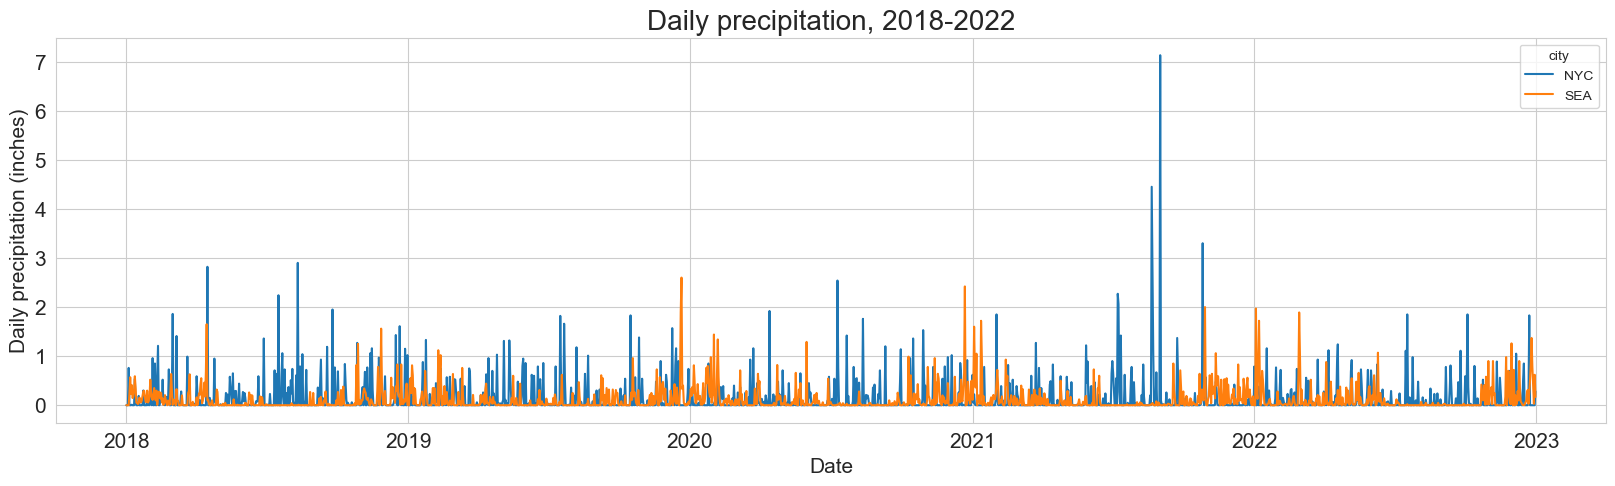

In [83]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=df, x="date", y="precipitation", hue="city")
plt.xlabel("Date", fontsize=15)
plt.ylabel("Daily precipitation (inches)", fontsize=15)
plt.title("Daily precipitation, 2018-2022", fontsize=20)
plt.tick_params(labelsize=15)
plt.show()

Daily precipitation is spiky in both cities: many days with little or no rain and occasional heavy days. NYC has the single biggest spike (about 7 inches, in late summer 2021), well above Seattle's largest day. Because the two lines overlap and are so jagged, it is hard to tell by eye which city gets more rain, so we need numerical summaries.

### Calculate basic descriptive statistics using groupby and describe
**Purpose:** use `groupby` and `describe` to compute the count, mean, standard deviation, quartiles, and extremes of daily precipitation for each city.

In [86]:
df[['city', 'precipitation']].groupby('city').describe()

precipitation                                                
             count      mean       std  min  25%   50%   75%   max
city                                                              
NYC         1826.0  0.147842  0.388334  0.0  0.0  0.00  0.08  7.13
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.60

### Compare mean precipitation values averaged over all days

In [88]:
df[['city', 'precipitation']].groupby('city').mean()

,precipitation
city,
NYC,0.147842
SEA,0.113270


NYC's mean daily precipitation (about 0.148 inches) is higher than Seattle's (about 0.113 inches). The medians are near zero for both (0.00 for NYC and 0.01 for Seattle), which means more than half of the days are dry or nearly dry, and the mean is pulled up by a few heavy days. NYC is also more variable (standard deviation 0.39 vs. 0.24) with a much larger maximum (7.13 vs. 2.60 inches). At the 75th percentile Seattle (0.12) is slightly above NYC (0.08), a first hint that Seattle has more light-rain days.

### Create a bar plot of mean daily precipitation for each city
**Purpose:** show the difference in the mean daily precipitation between the cities as a bar chart, which is easier to read than a table.

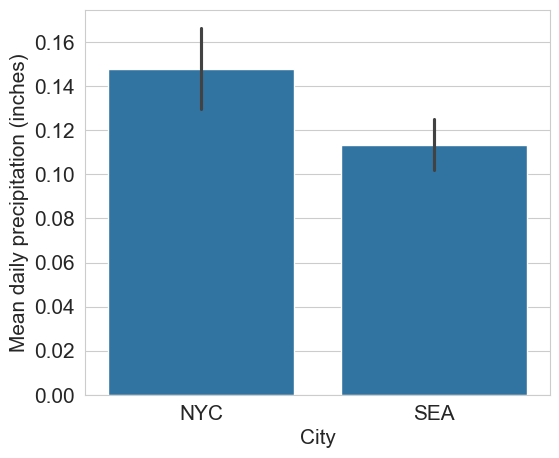

In [91]:
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x="city", y="precipitation")
plt.xlabel("City", fontsize=15)
plt.ylabel("Mean daily precipitation (inches)", fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

The bars repeat the table: NYC's mean daily precipitation is higher than Seattle's. The black lines on top of each bar are error bars, explained in the next section.

### Check the meaning of error bars in the Seaborn bar plot function
**Purpose:** by default `sns.barplot` draws a 95% confidence interval for the mean (computed by bootstrapping), not the standard deviation. To see the difference, draw the bars twice: once with the default confidence interval and once with `errorbar="sd"`.

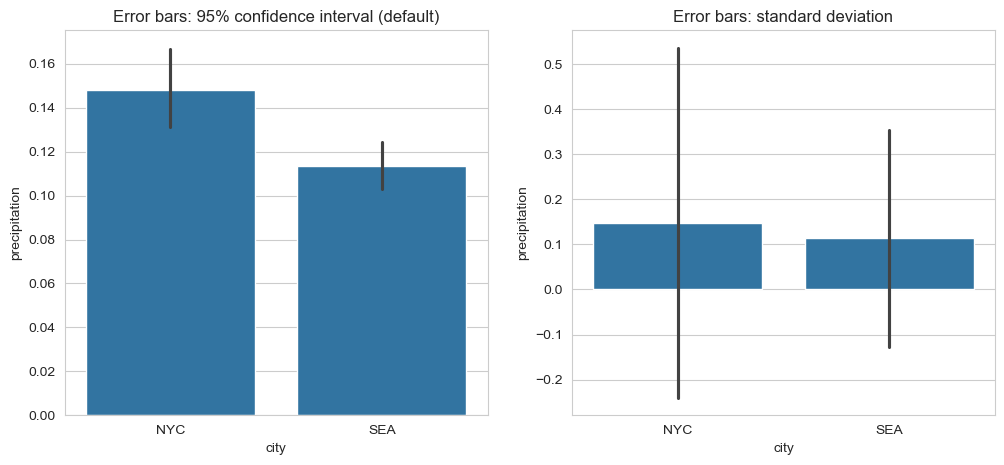

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x="city", y="precipitation", errorbar=("ci", 95), ax=axes[0])
axes[0].set_title("Error bars: 95% confidence interval (default)")
sns.barplot(data=df, x="city", y="precipitation", errorbar="sd", ax=axes[1])
axes[1].set_title("Error bars: standard deviation")
plt.show()

The confidence-interval bars (left) are short because they describe the uncertainty of the mean: roughly 0.13 to 0.17 inches for NYC and 0.10 to 0.12 inches for Seattle, so they just about separate (they do not overlap much, if at all). 

The standard-deviation bars (right) are much longer because they describe how much individual days vary, and they extend below zero, which is impossible for precipitation and shows that the daily values are not symmetric. So NYC's higher mean looks real rather than random noise, with the caveat that rainy days come in streaks, so the days are not independent and the interval is somewhat optimistic.

### Add a new column to the data frame indicating the month
**Purpose:** create a `month` variable (1-12) from the date, so we can study the seasonal pattern.

In [97]:
df["month"] = pd.DatetimeIndex(df["date"]).month
df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,NYC,0.00,1,1
1,2018-01-02,NYC,0.00,2,1
2,2018-01-03,NYC,0.00,3,1
3,2018-01-04,NYC,0.76,4,1
4,2018-01-05,NYC,0.00,5,1


In [98]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

Each row now has its month number; the first rows are January 2018. This variable is used to group and plot the data by month below.

### Create a box plot of precipitation by month for each city
**Purpose:** compare the full distribution of daily precipitation in each month for the two cities. A box shows the middle 50% of days (from the 25th to the 75th percentile) with a line at the median; dots are outliers.

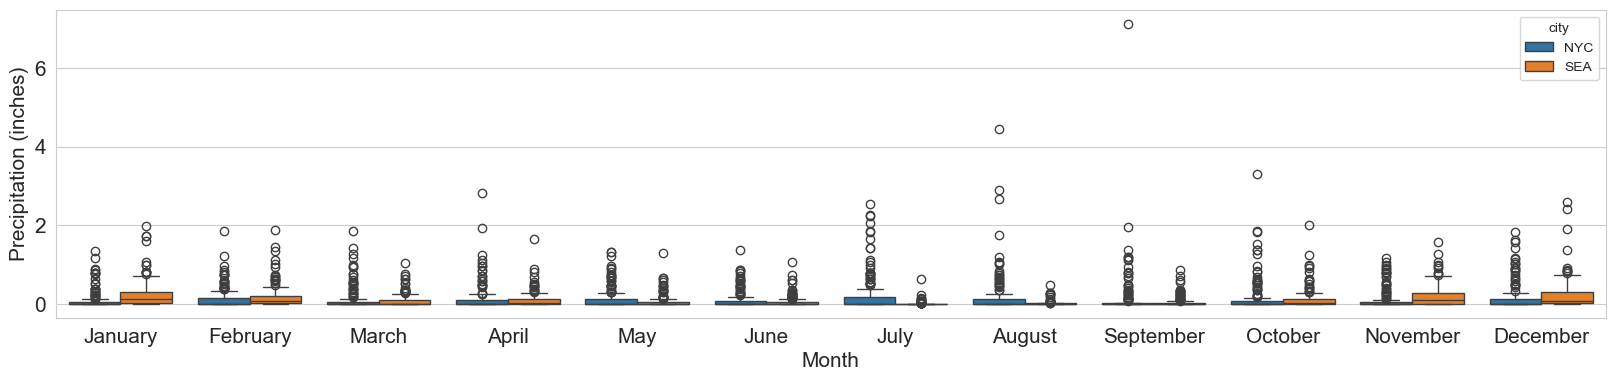

In [101]:
plt.figure(figsize=(20, 4))
sns.boxplot(data=df, x="month", y="precipitation", hue="city")
plt.xlabel("Month", fontsize=15)
plt.ylabel("Precipitation (inches)", fontsize=15)
plt.tick_params(labelsize=15)

#Get month names and set as x-axis tick labels
import calendar
month_names = list(calendar.month_name[1:])
plt.xticks(ticks=range(12), labels=month_names)
plt.show()

The boxes are small and squeezed at the bottom, and many dots appear above them. This is because most days have little rain and a few extreme days (such as NYC's 7 inches) stretch the axis. The extremes make the boxes hard to read, so the next section zooms in.

### Modify the box plot to adjust orientation and axis limits
**Purpose:** make the box plot readable by switching to horizontal boxes (`orient="h"`) and limiting the axis to 0-1.5 inches. The limit only changes the view: the extreme days are still in the data.

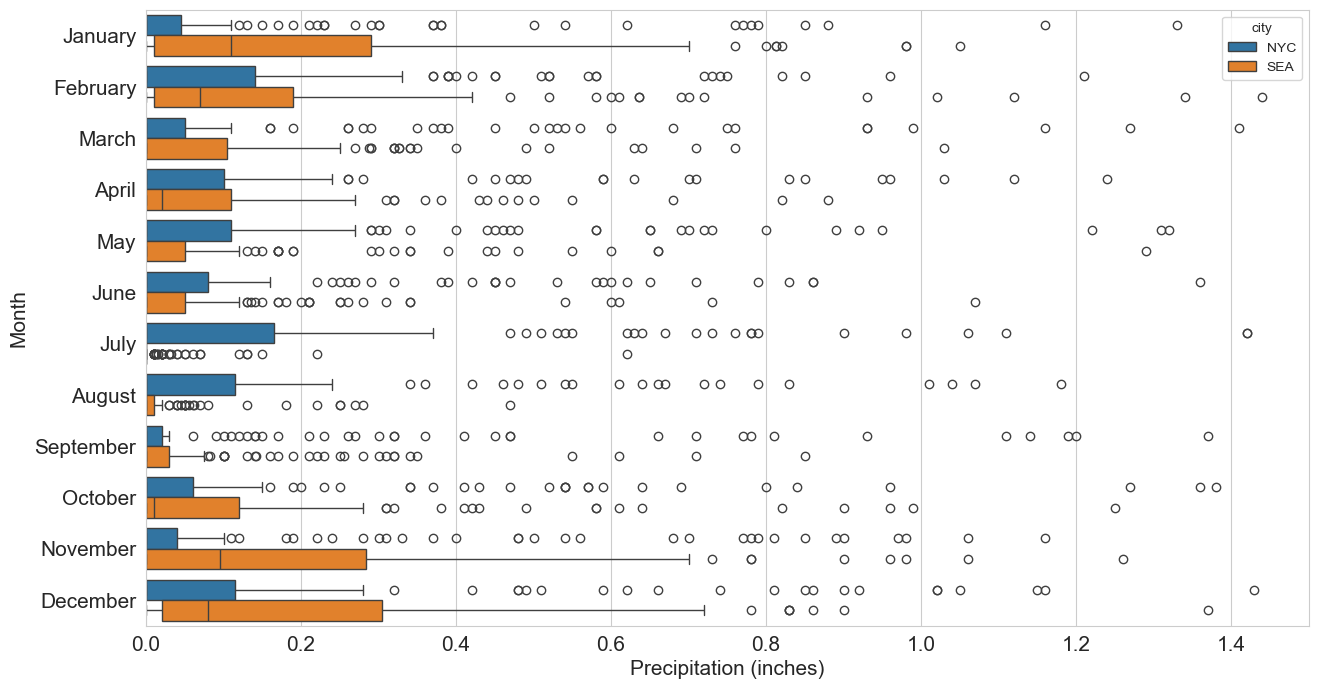

In [104]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, x="precipitation", y="month", hue="city", orient="h")
plt.ylabel("Month", fontsize=15)
plt.xlabel("Precipitation (inches)", fontsize=15)
plt.tick_params(labelsize=15)
plt.yticks(ticks=range(12), labels=month_names)
plt.xlim(0, 1.5)
plt.show()

NYC's median is 0 in every month, so its boxes start at zero and extend only to about 0.02-0.17 inches. Seattle's median is clearly above zero from November through February (about 0.07-0.11 inches) and its upper quartile reaches about 0.28-0.31 inches in November, December, and January, showing more frequent and heavier rain in the cool season. From May to August, Seattle's boxes shrink to almost nothing, since summer is mostly dry. In summer NYC's boxes are wider than Seattle's. A few days above 1.5 inches fall outside this zoomed view.

### Create a bar plot of mean precipitation by month for each city
**Purpose:** compare the mean daily precipitation of the two cities in each month, to see in which seasons each city is wetter.

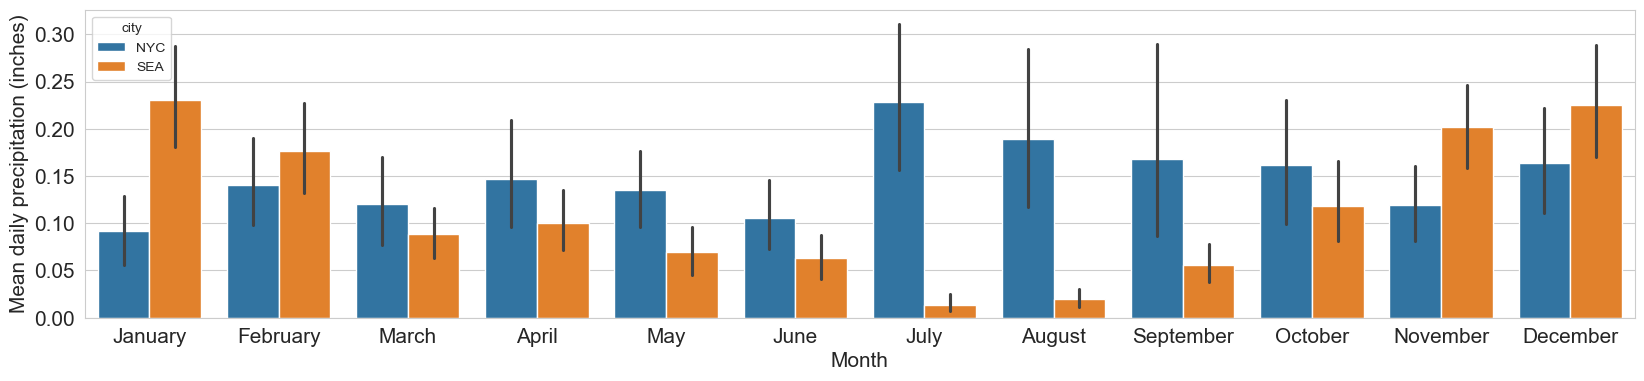

In [107]:
plt.figure(figsize=(20, 4))
sns.barplot(data=df, x="month", y="precipitation", hue="city")
plt.xlabel("Month", fontsize=15)
plt.ylabel("Mean daily precipitation (inches)", fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)
plt.show()

The two cities have opposite seasonal patterns. Seattle's bars are tall in winter (November to February) and very short in July and August. NYC's bars vary less across the year (about 0.09 to 0.23 inches) and are highest in July and August. The error bars are long in several months, so small differences (for example in May) should not be over-interpreted.

### Calculate mean precipitation by city and month using groupby
**Purpose:** compute the exact monthly means behind the previous plot. `unstack` puts the cities side by side so each month can be compared directly.

In [110]:
df[["month", "precipitation", "city"]].groupby(["city", "month"]).mean()

precipitation
city month               
NYC  1           0.092194
     2           0.140922
     3           0.120129
     4           0.146933
     5           0.134710
     6           0.105800
     7           0.228645
     8           0.189355
     9           0.168067
     10          0.162129
     11          0.118867
     12          0.164065
SEA  1           0.230742
     2           0.176472
     3           0.089075
     4           0.100483
     5           0.069161
     6           0.063167
     7           0.013984
     8           0.019995
     9           0.055622
     10          0.118452
     11          0.201867
     12          0.224903

Seattle is wetter in four months: November (0.202 vs. 0.119 inches per day), December (0.225 vs. 0.164), January (0.231 vs. 0.092), and February (0.176 vs. 0.141). NYC is wetter in the other eight months, March through October. The largest gaps are in summer: July (NYC 0.229 vs. Seattle 0.014) and August (0.189 vs. 0.020). Even though Seattle is known as the rainy city, NYC averages more precipitation in most of the year.

### Add a new column indicating if any precipitation occurred
**Purpose:** create a True/False column that is True when the day had any precipitation (more than 0 inches). This lets us study how *often* it rains, not just how much.

In [113]:
df["any_precipitation"] = df["precipitation"] > 0
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,NYC,0.00,1,1,False
1,2018-01-02,NYC,0.00,2,1,False
2,2018-01-03,NYC,0.00,3,1,False
3,2018-01-04,NYC,0.76,4,1,True
4,2018-01-05,NYC,0.00,5,1,False


Each row now shows whether that day had any precipitation. The first rows show a mix of True and False values, consistent with many dry days.

### Calculate and plot the proportion of days with any precipitation
**Purpose:** the mean of a True/False column is the proportion of True values, so averaging `any_precipitation` gives the fraction of rainy days. Compute it overall and by month.

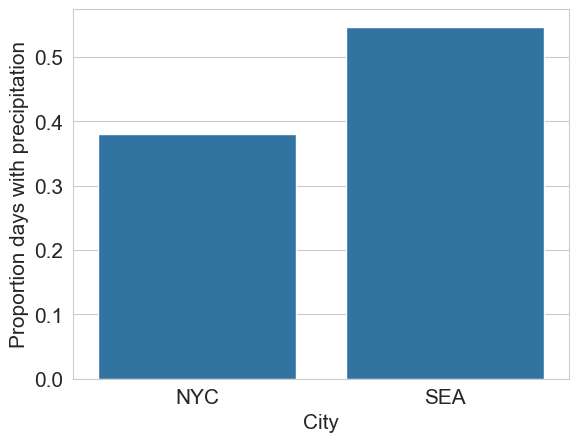

In [116]:
sns.barplot(data=df, x="city", y="any_precipitation", errorbar=None)
plt.xlabel("City", fontsize=15)
plt.ylabel("Proportion days with precipitation", fontsize=15)
plt.tick_params(labelsize =15)
plt.show()

Seattle has precipitation on about 55% of days compared with about 38% in NYC, which reverses the earlier result: Seattle rains more often, even though NYC gets more rain in total. 

#### Plot the proportion of days with precipitation each month

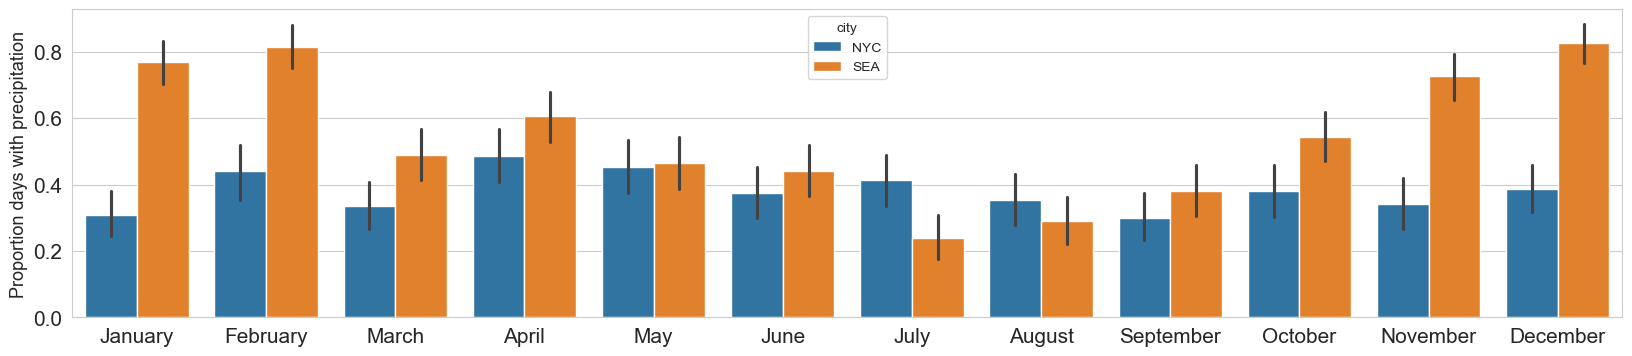

In [119]:
plt.figure(figsize=(20, 4))
sns.barplot(data=df, x="month", y="any_precipitation", hue="city")
plt.xlabel(None)
plt.ylabel("Proportion days with precipitation", fontsize=13)
plt.xticks(ticks=range(12), labels=month_names)
plt.tick_params(labelsize =15)
plt.show()

By month, Seattle has rain on 70-80% of days from November to February, but only about 25% in July. NYC stays within roughly 30-50% in every month, and has a higher share of rainy days than Seattle in July and August.

### Create additional graphs and summaries to further explore the data
#### Total precipitation per year
**Purpose:** answer the research question directly by adding up each year's precipitation for each city.

city,NYC,SEA
year,,
2018,65.6,37.2
2019,53.0,38.7
2020,45.4,43.2
2021,59.7,44.4
2022,46.3,43.3


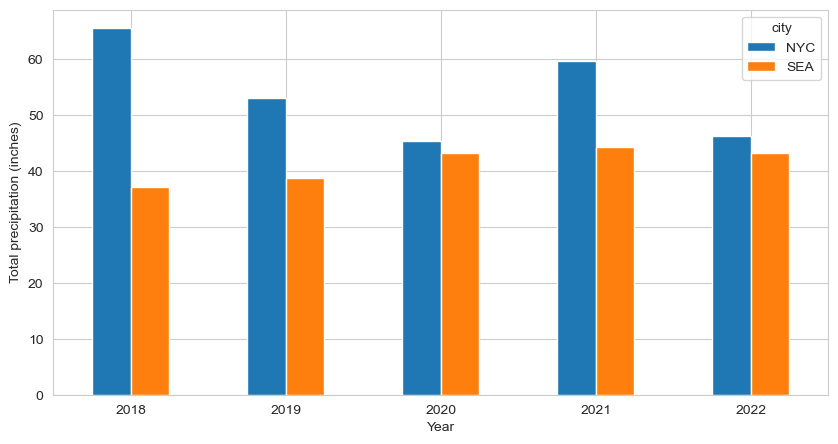

In [122]:
df["year"] = pd.DatetimeIndex(df["date"]).year
yearly_total = df.groupby(["year", "city"])["precipitation"].sum().unstack(level="city").round(1)
display(yearly_total)

yearly_total.plot(kind="bar", figsize=(10, 5))
plt.xlabel("Year")
plt.ylabel("Total precipitation (inches)")
plt.xticks(rotation=0)
plt.show()

NYC received more precipitation than Seattle in every year, but the gap varies: it is large in 2018 (65.6 vs. 37.2 inches) and small in 2020 (45.4 vs. 43.2) and 2022 (46.3 vs. 43.3). Over the five years NYC totals about 270 inches and Seattle about 207 (Seattle's total includes the imputed days). Seattle's yearly totals are steadier (37-44 inches) than NYC's (45-66 inches).

## 3. Modeling

### Perform a statistical test for differences in the mean precipitation each month between the cities
**Purpose:** before testing, look at the distribution of daily precipitation in one month (January) for both cities. The tests compare averages, so it helps to know what the data looks like.

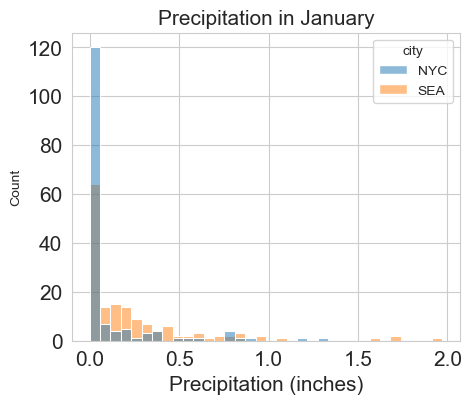

In [126]:
plt.figure(figsize=(5, 4))
sns.histplot(data=df.loc[df['month'] == 1], x="precipitation", hue="city")
plt.xlabel("Precipitation (inches)", fontsize=15)
plt.title("Precipitation in January", fontsize=15)

plt.tick_params(labelsize=15)
plt.show()

In January, precipitation is highly skewed in both cities. There are many days with little or no precipitation and a few heavy days. NYC has more dry days than Seattle, and Seattle has more days with small to moderate amounts. Skewed data means a few heavy days influence the averages a lot, which is one reason the tests below should be read with care.

**Purpose:** for each month, test whether Seattle and NYC differ in mean daily precipitation. 

The hypotheses for month *m* are $H_0: \mu_{\text{Seattle},m} = \mu_{\text{NYC},m}$ against $H_a: \mu_{\text{Seattle},m} \neq \mu_{\text{NYC},m}$ (two-sided, because either city might be rainier). We use Welch's t-test, which does not assume equal variances, and a 5% significance level. These tests assume the five years are a random sample of years and that days are independent, which is only approximately true.

In [129]:
from scipy import stats
significance_level = 0.05
significantly_different = np.zeros(12)

# Perform t-test for each month
for month in range(1, 13):
    # Get precipitation data for Seattle and NYC for the current month
    sea_data = df.loc[(df['city'] == 'SEA') & (df['month'] == month), 'precipitation']
    nyc_data = df.loc[(df['city'] == 'NYC') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, nyc_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1] = 1
    print(f"Month {month}:")
    print(f"t-statistic = {t_statistic:.2f}")
    print(f"p-value t test = {p_value:.3f}")
    print("-" * 20)

Month 1:
t-statistic = 4.21
p-value t test = 0.000
--------------------
Month 2:
t-statistic = 1.04
p-value t test = 0.298
--------------------
Month 3:
t-statistic = -1.14
p-value t test = 0.256
--------------------
Month 4:
t-statistic = -1.38
p-value t test = 0.170
--------------------
Month 5:
t-statistic = -2.59
p-value t test = 0.010
--------------------
Month 6:
t-statistic = -1.94
p-value t test = 0.053
--------------------
Month 7:
t-statistic = -5.34
p-value t test = 0.000
--------------------
Month 8:
t-statistic = -3.92
p-value t test = 0.000
--------------------
Month 9:
t-statistic = -2.08
p-value t test = 0.040
--------------------
Month 10:
t-statistic = -1.09
p-value t test = 0.276
--------------------
Month 11:
t-statistic = 2.67
p-value t test = 0.008
--------------------
Month 12:
t-statistic = 1.46
p-value t test = 0.146
--------------------


At the 0.05 level, months 1, 5, 7, 8, 9, and 11 are significantly different. Seattle is higher in January and November, and NYC is higher in May, July, August, and September.

### Plot the mean precipitation each month with a star for significant differences

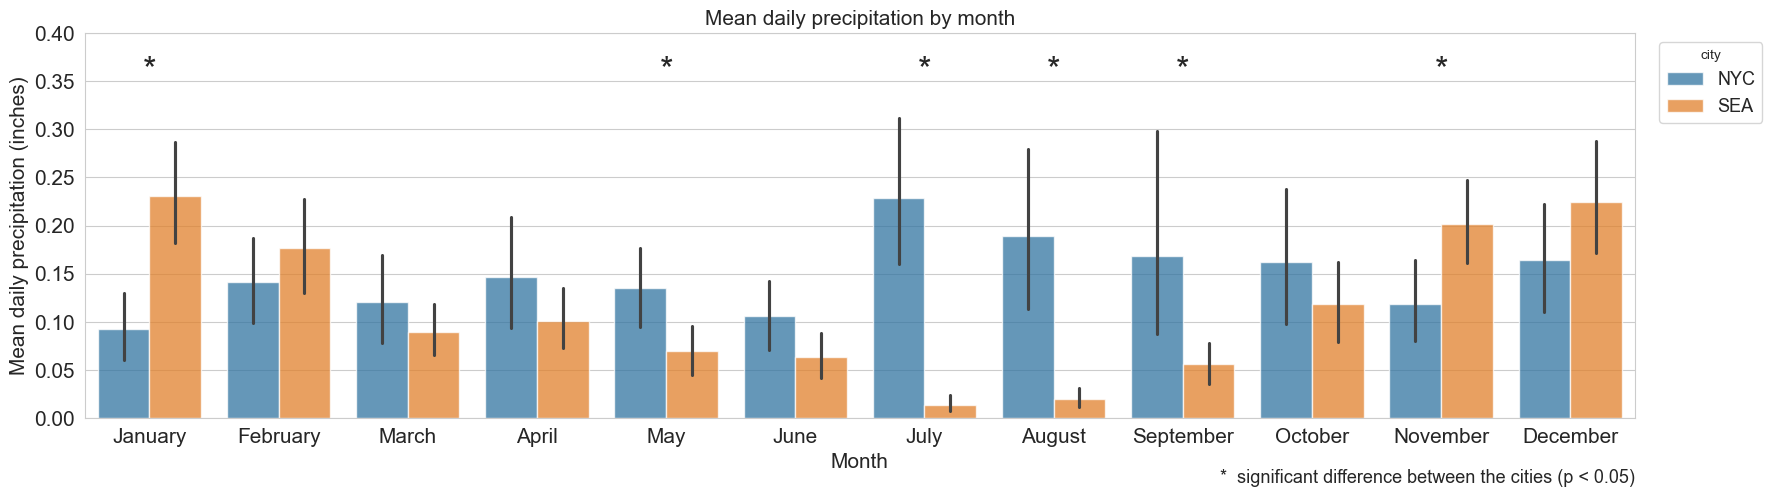

In [132]:
plt.figure(figsize=(20, 5))
sns.barplot(data=df, x='month', y='precipitation', hue='city', alpha=0.75)
plt.xlabel('Month', fontsize=15)
plt.ylabel('Mean daily precipitation (inches)', fontsize=15)
plt.title('Mean daily precipitation by month', fontsize=15) 

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)
plt.ylim(0, 0.40)

# Add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:
        plt.text(month, 0.35, '*', ha='center', fontsize=25)

# Legend outside the plot, and a note explaining the star
plt.legend(title='city', loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=13)
plt.figtext(0.9, -0.02, '*  significant difference between the cities (p < 0.05)', ha='right', fontsize=13)
plt.show()

Stars mark the months where the t-test finds a significant difference (p < 0.05) in mean daily precipitation: January and November (Seattle higher) and May, July, August, and September (NYC higher). These p-values are not adjusted for running 12 tests, so a few of these months could be false positives. The clearest differences are in January, July, and August, where the p-values are well below 0.01.

### Perform a statistical test for differences in the proportion of days with any precipitation each month between the cities
**Purpose:** for each month, test whether the proportion of days with precipitation differs between the cities: $H_0: p_{\text{Seattle},m} = p_{\text{NYC},m}$ against $H_a: p_{\text{Seattle},m} \neq p_{\text{NYC},m}$, using a two-sided two-proportion z-test at the 5% level.

In [135]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

# Perform t-test for each month
for month in range(1, 13):
    # Create a contingency table for Seattle and NYC for the current month
    contingency_table = pd.crosstab(
        df.loc[df['month'] == month, 'city'], df.loc[df['month'] == month, 'any_precipitation'])
    
    # Calculate the number of True values (days with precipitation) for each city
    days_with_precipitation = contingency_table[True]
    
    # Calculate the total number of days for each city
    total_counts = contingency_table.sum(axis=1)
    
    #Hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided')
    
    if p_value < significance_level:
        significantly_different_proportion[month-1] = 1

    print(f"Month {month}:")
    print(f"z-statistic = {zstat:.2f}")
    print(f"p-value = {p_value:.3f}")
    print("-" * 20)

Month 1:
z-statistic = -8.09
p-value = 0.000
--------------------
Month 2:
z-statistic = -6.53
p-value = 0.000
--------------------
Month 3:
z-statistic = -2.77
p-value = 0.006
--------------------
Month 4:
z-statistic = -2.09
p-value = 0.037
--------------------
Month 5:
z-statistic = -0.23
p-value = 0.820
--------------------
Month 6:
z-statistic = -1.18
p-value = 0.240
--------------------
Month 7:
z-statistic = 3.27
p-value = 0.001
--------------------
Month 8:
z-statistic = 1.21
p-value = 0.224
--------------------
Month 9:
z-statistic = -1.46
p-value = 0.144
--------------------
Month 10:
z-statistic = -2.85
p-value = 0.004
--------------------
Month 11:
z-statistic = -6.71
p-value = 0.000
--------------------
Month 12:
z-statistic = -7.91
p-value = 0.000
--------------------


At the 5% level, eight months show a significant difference in the proportion of days with precipitation: January, February, March, April, October, November, and December (p < 0.05) and July (p = 0.001). In crosstab the cities are sorted alphabetically (NYC first), so a negative z-statistic means Seattle has the higher proportion and a positive one means NYC does. Seattle is higher in seven of these months (z from -8.09 to -2.09), and NYC is higher only in July (z = 3.27). May, June, August, and September show no significant difference.

**Purpose:** show the table of counts that feeds the z-test for one month (January): the number of days without and with precipitation in each city.

In [138]:
contingency_table = pd.crosstab(
    df.loc[df['month'] == 1, 'city'], df.loc[df['month'] == 1, 'any_precipitation'])
contingency_table

any_precipitation,False,True
city,,
NYC,107,48
SEA,36,119


In January, NYC had precipitation on 48 of 155 days (31%) and Seattle on 119 of 155 days (77%). This large gap is why the z-statistic for January is so large (-8.09).

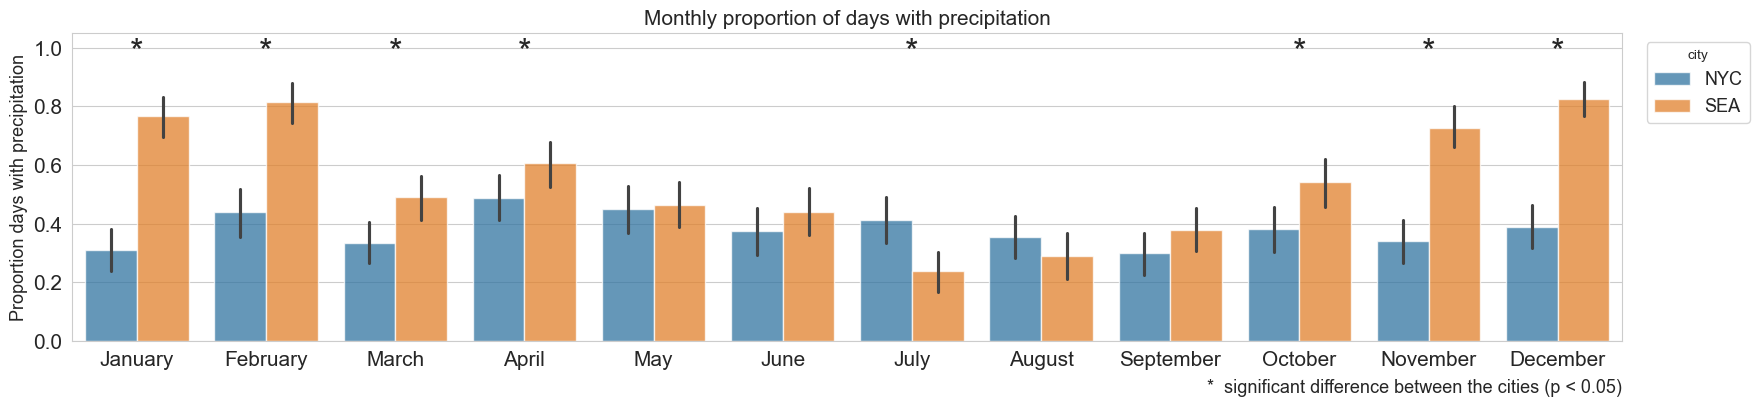

In [140]:
plt.figure(figsize=(20, 4))
sns.barplot(data=df, x='month', y='any_precipitation', hue='city', alpha=0.75)
plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('Monthly proportion of days with precipitation', fontsize=15) 

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)
plt.ylim(0, 1.05)

# Add stars for significantly different months
for month in range(12):
    if significantly_different_proportion[month] == 1:
        plt.text(month, 0.95, '*', ha='center', fontsize=25)

# Legend outside the plot, and a note explaining the star
plt.legend(title='city', loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=13)
plt.figtext(0.9, -0.02, '*  significant difference between the cities (p < 0.05)',
            ha='right', fontsize=13)
plt.show()

The stars mark the months with a significant difference in the proportion of rainy days. Seattle rains on far more days in the winter, about ~ 70-80% of days from November to February compared with ~ 30-44% in NYC. NYC has more rainy days in July (~ 40% vs. ~ 25%). The 190 imputed Seattle days all count as rainy, which inflates Seattle's proportions slightly, mainly in March and April.

## 4. Checking the effect of the filled-in Seattle days

### Repeat the proportion test using only recorded days
**Purpose:** 190 Seattle days were missing and were filled with day-of-year averages. An average is almost never exactly zero, so every filled-in day counts as a "day with precipitation". To see how much this matters, remove the filled-in days and repeat the monthly proportion test with the days that were actually recorded.

In [144]:
raw_seattle = pd.read_csv("../data/seattle_rain.csv")
raw_seattle["DATE"] = pd.to_datetime(raw_seattle["DATE"], format="%m/%d/%y")
recorded_dates = set(raw_seattle.dropna(subset=["PRCP"])["DATE"])

is_recorded = (df["city"] == "NYC") | df["date"].isin(recorded_dates)
df_recorded = df[is_recorded]
print("Filled-in Seattle days removed:", (~is_recorded).sum())


def proportion_test_p_values(data):
    p_values = []
    for month in range(1, 13):
        counts = pd.crosstab(
            data.loc[data["month"] == month, "city"],
            data.loc[data["month"] == month, "any_precipitation"])
        _, p_value = proportions_ztest(
            count=counts[True], nobs=counts.sum(axis=1), alternative="two-sided")
        p_values.append(p_value)
    return np.array(p_values)


p_values_all_days = proportion_test_p_values(df)
p_values_recorded_days = proportion_test_p_values(df_recorded)

comparison = pd.DataFrame({
    "p-value, all days": p_values_all_days.round(3),
    "p-value, recorded days only": p_values_recorded_days.round(3),
    "significant, all days": p_values_all_days < 0.05,
    "significant, recorded days only": p_values_recorded_days < 0.05,
}, index=month_names)
comparison

Filled-in Seattle days removed: 190


,"p-value, all days","p-value, recorded days only","significant, all days","significant, recorded days only"
January,0.000,0.000,True,True
February,0.000,0.000,True,True
March,0.006,0.109,True,False
April,0.037,0.094,True,False
May,0.820,0.820,False,False
June,0.240,0.379,False,False
July,0.001,0.000,True,True
August,0.224,0.072,False,False
September,0.144,0.410,False,False
October,0.004,0.004,True,True


190 filled-in days were removed. Most conclusions do not change: January, February, July, October, November, and December remain significant when only recorded days are used. The exceptions are March and April: they are significant when the filled-in days are included (p = 0.006 and 0.037) but not with recorded days only (p = 0.109 and 0.094). Those two months depended on the filled-in days and should not be treated as clear differences.

## 5. Statistics reported in the report

### Total amount
**Purpose:** reproduce the numbers in the report's "The data" paragraph and in "Total amount": the days covered per city, the number of filled-in Seattle days, the total precipitation of each city over the five years, and the yearly difference.

In [148]:
days_per_city = df.groupby("city").size()
filled_in_days = (~is_recorded).sum()
print("Days per city:", days_per_city.to_dict())
print(f"Filled-in Seattle days: {filled_in_days} ({filled_in_days / days_per_city['SEA']:.0%} of Seattle's days)\n")

total_precipitation = df.groupby("city")["precipitation"].sum().round(0)
print("Total precipitation over five years (inches):")
print(total_precipitation.to_string(), "\n")

yearly_difference = (yearly_total["NYC"] - yearly_total["SEA"]).round(1)
print("NYC minus Seattle, total precipitation by year (inches):")
print(yearly_difference.to_string())
print("\nNYC had more precipitation than Seattle in every year:", (yearly_difference > 0).all())

Days per city: {'NYC': 1826, 'SEA': 1826}
Filled-in Seattle days: 190 (10% of Seattle's days)

Total precipitation over five years (inches):
city
NYC    270.0
SEA    207.0 

NYC minus Seattle, total precipitation by year (inches):
year
2018    28.4
2019    14.3
2020     2.2
2021    15.3
2022     3.0

NYC had more precipitation than Seattle in every year: True


Each city covers 1,826 days, and 190 Seattle days (10%) were filled in. Over the five years NYC received about 270 inches of precipitation and Seattle about 207. NYC had more in every year, but the gap was large in 2018 (28.4 inches), 2019 (14.3), and 2021 (15.3) and small in 2020 (2.2) and 2022 (3.0).

### The seasons differ
**Purpose:** reproduce the "seasons" results: the mean daily precipitation of each city in each month, which city is higher, and which months have a star (a significant difference) in Figure 2.

In [151]:
monthly_mean = df.groupby(["month", "city"])["precipitation"].mean().unstack("city")
seasons = pd.DataFrame({
    "NYC": monthly_mean["NYC"].round(2).values,
    "Seattle": monthly_mean["SEA"].round(2).values,
    "higher": np.where(monthly_mean["SEA"] > monthly_mean["NYC"], "Seattle", "NYC"),
}, index=month_names)
display(seasons)

print("Months with a star in Figure 2:",
      [month for month, star in zip(month_names, significantly_different) if star == 1])

,NYC,Seattle,higher
January,0.09,0.23,Seattle
February,0.14,0.18,Seattle
March,0.12,0.09,NYC
April,0.15,0.10,NYC
May,0.13,0.07,NYC
June,0.11,0.06,NYC
July,0.23,0.01,NYC
August,0.19,0.02,NYC
September,0.17,0.06,NYC
October,0.16,0.12,NYC


Months with a star in Figure 2: ['January', 'May', 'July', 'August', 'September', 'November']


Seattle has the higher mean daily precipitation in November, December, January, and February, and NYC has the higher mean from March to October. The summer gap is large: in July NYC averages 0.23 inches per day and Seattle 0.01. Figure 2 has a star for January, May, July, August, September, and November, the months where the t-test finds a significant difference.

### Frequency of rainy days
**Purpose:** reproduce the "frequency" results: the percentage of days with precipitation overall (with and without the filled-in days), the percentage by month, the winter ranges, and the months where NYC has more rainy days and where that difference is significant (the stars in Figure 3).

In [154]:
percent_days = (df.groupby("city")["any_precipitation"].mean() * 100).round(0)
percent_recorded_days = (df_recorded.groupby("city")["any_precipitation"].mean() * 100).round(0)
print("Percent of days with precipitation:", percent_days.to_dict())
print("Percent of days with precipitation, recorded days only:", percent_recorded_days.to_dict(), "\n")

percent_by_month = (df.groupby(["month", "city"])["any_precipitation"].mean().unstack("city") * 100).round(0)
percent_by_month.index = month_names
display(percent_by_month)

winter_months = ["November", "December", "January", "February"]
for city in ["SEA", "NYC"]:
    winter = percent_by_month.loc[winter_months, city]
    print(f"{city}, November to February: {winter.min():.0f}% to {winter.max():.0f}% of days")

star_months = [month for month, star in zip(month_names, significantly_different_proportion) if star == 1]
nyc_higher = list(percent_by_month.index[percent_by_month["NYC"] > percent_by_month["SEA"]])
print("\nMonths where NYC has more rainy days:", nyc_higher)
print("...of which significant (star in Figure 3):", [month for month in nyc_higher if month in star_months])
print("All months with a star in Figure 3:", star_months)

Percent of days with precipitation: {'NYC': 38.0, 'SEA': 55.0}
Percent of days with precipitation, recorded days only: {'NYC': 38.0, 'SEA': 51.0} 



city,NYC,SEA
January,31.0,77.0
February,44.0,82.0
March,34.0,49.0
April,49.0,61.0
May,45.0,46.0
June,37.0,44.0
July,41.0,24.0
August,35.0,29.0
September,30.0,38.0
October,38.0,54.0


SEA, November to February: 73% to 83% of days
NYC, November to February: 31% to 44% of days

Months where NYC has more rainy days: ['July', 'August']
...of which significant (star in Figure 3): ['July']
All months with a star in Figure 3: ['January', 'February', 'March', 'April', 'July', 'October', 'November', 'December']


Seattle has precipitation on about 55% of days compared with 38% in NYC (51% in Seattle if only the recorded days are used). 

From November to February the gap is large: 73% to 83% of days in Seattle versus 31% to 44% in NYC. NYC has more rainy days only in July (41% vs. 24%) and August (35% vs. 29%), and only July's difference is significant. Figure 3 has a star for January, February, March, April, July, October, November, and December.

## 6. Conclusion

Seattle rains more often, especially in winter. It has precipitation on about 55% of days compared with 38% in NYC, and from November to February on 73% to 83% of days compared with 31% to 44%. New York City gets more total precipitation (about 270 inches vs. 207 over the five years, and more in every year), because its summers are much wetter. In July NYC averages 0.23 inches per day and Seattle 0.01.

Seattle's reputation is therefore fair when it comes to how often it is wet, but not when it comes to how much rain falls.

However, the analysis covers only five years and one station per city, so it may not represent each whole city, and the five years may not be a random sample of years. The 190 filled-in Seattle days count as rainy days, which makes Seattle look slightly rainier (55% of days with them, 51% using only recorded days). The March and April differences in rainy days depend on those filled-in days (Section 4).